In [57]:
from itertools import combinations
import pandas as pd

# load raw festival dataset
df = pd.read_csv("../data/raw/festival_project_artists.csv")

# clean artist names (remove extra spaces)
df["artist_clean"] = df["artist_clean"].str.strip()

In [58]:
# Column 0 = festival
# Column 1 = artist name
festival_col = df.columns[0]
artist_col = df.columns[1]

grouped_festivals = df.groupby(festival_col)[artist_col]

festival_artists = {}

for festival_col, artist_col in grouped_festivals:
    unique_artists = set(artist_col)
    festival_artists[festival_col] = unique_artists

In [59]:
results = []

for festival_a, festival_b in combinations(festival_artists.keys(), 2):
    artists_a = festival_artists[festival_a]
    artists_b = festival_artists[festival_b]

    shared_artists = artists_a.intersection(artists_b)
    total_artists = artists_a.union(artists_b)

    similarity_score = round((len(shared_artists) / len(total_artists))*100,2)
  
    results.append({
        "festival_a": festival_a,
        "festival_b": festival_b,
        "shared_artists": len(shared_artists),
        "total_unique_artists": len(total_artists),
        "similarity_score": similarity_score,
    })

In [60]:
festival_similarity_df = pd.DataFrame(results)

festival_similarity_df = festival_similarity_df.sort_values(
    "similarity_score",
    ascending=False
)
festival_similarity_df.to_csv("../data/processed/festival_similarity.csv", index=False)
festival_similarity_df

,festival_a,festival_b,shared_artists,total_unique_artists,similarity_score
35,Lollapalooza,Outside Lands,32,235,13.62
3,Bonnaroo,Governors Ball,18,152,11.84
29,Governors Ball,Outside Lands,14,140,10.00
28,Governors Ball,Lollapalooza,21,214,9.81
7,Bonnaroo,Outside Lands,16,186,8.60
6,Bonnaroo,Lollapalooza,22,261,8.43
17,EDC,Hard Summer,35,427,8.20
15,EDC,Electric Forest,31,481,6.44
13,Coachella,Lollapalooza,19,306,6.21
22,Electric Forest,Hard Summer,11,191,5.76


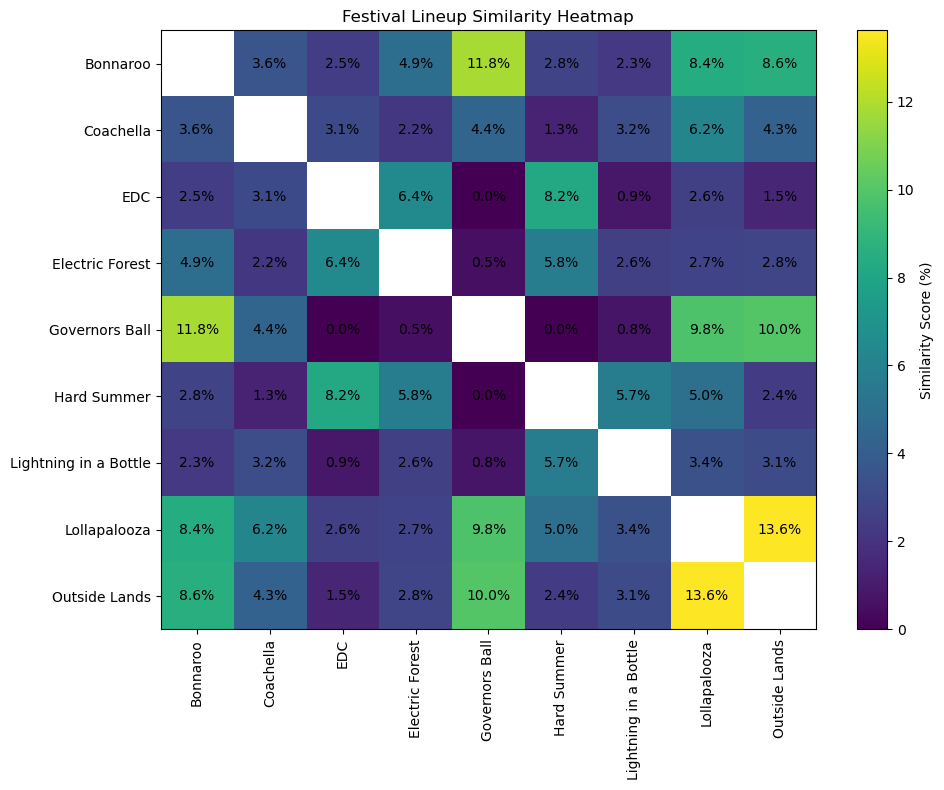

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Remove diagonal values so 100% self-similarity does not affect the color scale
for festival in heatmap_df.index:
    heatmap_df.loc[festival, festival] = np.nan

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_df, aspect="auto")
plt.colorbar(label="Similarity Score (%)")

# Add percentage labels inside each cell
for row_index in range(len(heatmap_df.index)):
    for col_index in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[row_index, col_index]

        if not np.isnan(value):
            plt.text(col_index, row_index, f"{value:.1f}%", ha="center", va="center")

plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=90)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

plt.title("Festival Lineup Similarity Heatmap")
plt.tight_layout()
filename = f"../visuals/festival_similarity_heatmap.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
